## Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, auc
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
RND = 123
#MLflow Setup
EXPERIMENT_NAME = "asserMLfinalSubmission"
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment(EXPERIMENT_NAME)
#Helper for MLflow Logging
def log_run(run_name, model, params, metrics, artifacts=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        if artifacts:
            for key, path in artifacts.items():
                mlflow.log_artifact(path)
        if hasattr(model, "predict"):
             mlflow.sklearn.log_model(model, "model")

utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlitmlflow.db') to take advantage of the latest MLflow features. See http18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2025/12/20 20:32:39 INFO mlflow.tracking.fluent: Experiment with name 'asserMLfinalSubmission' does not exist. Creating a new experiment.


## Load Data

In [4]:
file_path = r"customer_churn_business_dataset.csv"
df = pd.read_csv(file_path)
print("Data Shape:", df.shape)
df.head()

Data Shape: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## Test for Nulls

In [6]:
print("Raw Data Null Count :")
print(df.isnull().sum())

Raw Data Null Count :
customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn            

This output shows us the count of null values in each column. Currently, the data might be clean or have some missing values, but checking this is crucial before start.

## Adding Nulls

In [9]:
#Using columns age,tenure months,referral count,payment failures,last login days ago
cols_to_null = ["age", "tenure_months", "referral_count","payment_failures","last_login_days_ago"] 
#Ensure these exist
int_cols = [c for c in cols_to_null if c in df.columns]
if not int_cols:
    int_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:3]
print(f"Adding nulls into: {int_cols}")
for col in int_cols:
    df.loc[df.sample(frac=0.10, random_state=RND).index, col] = np.nan
print("Adding nulls completed.")

Adding nulls into: ['age', 'tenure_months', 'referral_count', 'payment_failures', 'last_login_days_ago']
Adding nulls completed.


## Check Nulls After Injection

In [11]:
print("After adding nulls:")
print(df.isnull().sum())

After adding nulls:
customer_id                  0
gender                       0
age                       1000
country                      0
city                         0
customer_segment             0
tenure_months             1000
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago       1000
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures          1000
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count            1000
churn              

Now we can clearly see the missing values in 'age', 'tenure_mo', and 'referral_count' , 'payment_failures',last_login_days_ago. This confirms that our injection worked and we need to fix these specific columns.

## Split Dataset

In [14]:
# Define Target
target_col = 'churn'
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
X = df.drop(columns=[target_col])
y = df[target_col]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RND, stratify=y)
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)

Train shape: (8000, 30)
Test shape: (2000, 30)


I splitted the Dataset into 80 20 Ratio.

## Check Duplicates

In [17]:
print("Duplicates in training:", X_train_raw.duplicated().sum())

Duplicates in training: 0


## Mean and Variance Before Imputation

In [19]:
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
print("     Mean before imputation")
print(X_train_raw[num_cols].mean())
print("\n     Variance before imputation")
print(X_train_raw[num_cols].var())

     Mean before imputation
age                       45.931265
tenure_months             30.203005
monthly_logins            19.696500
weekly_active_days         3.476125
avg_session_time          15.165435
features_used              4.988500
usage_growth_rate          0.019969
last_login_days_ago        9.399054
monthly_fee               34.952500
total_revenue           1059.510000
payment_failures           0.505913
support_tickets            1.206375
avg_resolution_time       23.946206
csat_score                 3.478875
escalations                0.295500
email_open_rate            0.497707
marketing_click_rate       0.252817
nps_score                 19.127625
referral_count             0.992626
dtype: float64

     Variance before imputation
age                     2.669020e+02
tenure_months           2.926272e+02
monthly_logins          9.657221e+01
weekly_active_days      5.307843e+00
avg_session_time        4.679649e+01
features_used           4.867726e+00
usage_growth_rate 

We calculated the mean and variance to have a baseline. After imputation, we will check these again to ensure that we didn't  change the data distribution.

## KNN Imputation

In [22]:
#KNN Imputation
knn_imputer = KNNImputer(n_neighbors=8)
#Fit on train, transform both
X_train_num_imputed = pd.DataFrame(knn_imputer.fit_transform(X_train_raw[num_cols]), columns=num_cols, index=X_train_raw.index)
X_test_num_imputed = pd.DataFrame(knn_imputer.transform(X_test_raw[num_cols]), columns=num_cols, index=X_test_raw.index)
#Update original dataframes with imputed values
X_train_imp = X_train_raw.copy()
X_test_imp = X_test_raw.copy()
X_train_imp[num_cols] = X_train_num_imputed
X_test_imp[num_cols] = X_test_num_imputed
print("Imputation Done.")

Imputation Done.


## Mean and Variance After Imputation

In [24]:
print("     Mean after imputation")
print(X_train_imp[num_cols].mean())
print("\n      Variance after imputation")
print(X_train_imp[num_cols].var())

     Mean after imputation
age                       45.933563
tenure_months             30.230078
monthly_logins            19.696500
weekly_active_days         3.476125
avg_session_time          15.165435
features_used              4.988500
usage_growth_rate          0.019969
last_login_days_ago        9.431516
monthly_fee               34.952500
total_revenue           1059.510000
payment_failures           0.505906
support_tickets            1.206375
avg_resolution_time       23.946206
csat_score                 3.478875
escalations                0.295500
email_open_rate            0.497707
marketing_click_rate       0.252817
nps_score                 19.127625
referral_count             0.992484
dtype: float64

      Variance after imputation
age                     2.430976e+02
tenure_months           2.869669e+02
monthly_logins          9.657221e+01
weekly_active_days      5.307843e+00
avg_session_time        4.679649e+01
features_used           4.867726e+00
usage_growth_rate  

## Outlier Check (IQR)

In [26]:
outlier_summary = {}
for col in num_cols:
    Q1 = X_train_imp[col].quantile(0.25)
    Q3 = X_train_imp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    lower_outliers = (X_train_imp[col] < lower).sum()
    upper_outliers = (X_train_imp[col] > upper).sum()
    total_outliers = lower_outliers + upper_outliers
    outlier_summary[col] = {
        "Lower Outliers": lower_outliers,
        "Upper Outliers": upper_outliers,
        "Total Outliers": total_outliers}
outlier_table = pd.DataFrame(outlier_summary).T
print(outlier_table)

                      Lower Outliers  Upper Outliers  Total Outliers
age                                0               0               0
tenure_months                      0               0               0
monthly_logins                     0              33              33
weekly_active_days                 0               0               0
avg_session_time                   0              19              19
features_used                      0              93              93
usage_growth_rate                 32              30              62
last_login_days_ago                0             369             369
monthly_fee                        0             419             419
total_revenue                      0             427             427
payment_failures                   0              94              94
support_tickets                    0              14              14
avg_resolution_time                0              35              35
csat_score                       1

## Scaling and Encoding

In [28]:
#Categorical Columns
cat_cols = X_train_imp.select_dtypes(include=['object', 'bool']).columns.tolist()
X_train_enc = X_train_imp.copy()
X_test_enc = X_test_imp.copy()
#Label Encoding
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    X_test_enc[col] = le.transform(X_test_enc[col].astype(str))
    le_dict[col] = le
#Standard Scaling for Numerical
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])
print("Encoding and scaling complete.")

Encoding and scaling complete.


## Handle Outliers (Isolation Forest)

In [30]:
print("      Handling Outliers with Isolation Forest")
# Use ALL columns (Numeric + Encoded Categorical)
iso = IsolationForest(contamination=0.05, random_state=RND)
yhat = iso.fit_predict(X_train_enc)
#Mask for inliers
mask = yhat != -1
X_train_clean = X_train_enc[mask]
y_train_clean = y_train[mask]
print(f"Original shape: {X_train_imp.shape}, Cleaned shape: {X_train_clean.shape}")
# Set variables for next steps
X_train_final = X_train_clean
y_train_final = y_train_clean.astype(int)
X_test_final = X_test_enc
y_test_final = y_test.astype(int)

      Handling Outliers with Isolation Forest
Original shape: (8000, 30), Cleaned shape: (7600, 30)


## Target Distribution

2188794874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_clean, palette='pastel')


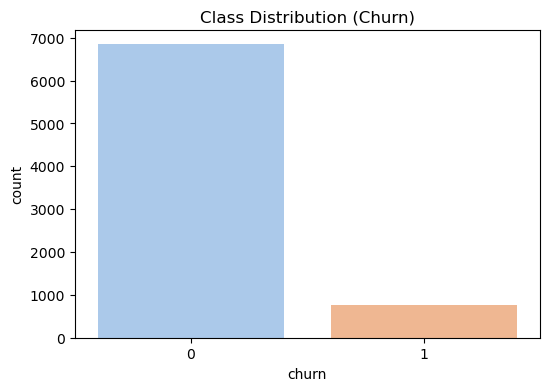

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_clean, palette='pastel')
plt.title("Class Distribution (Churn)")
plt.show()

## Feature Correlation with Target

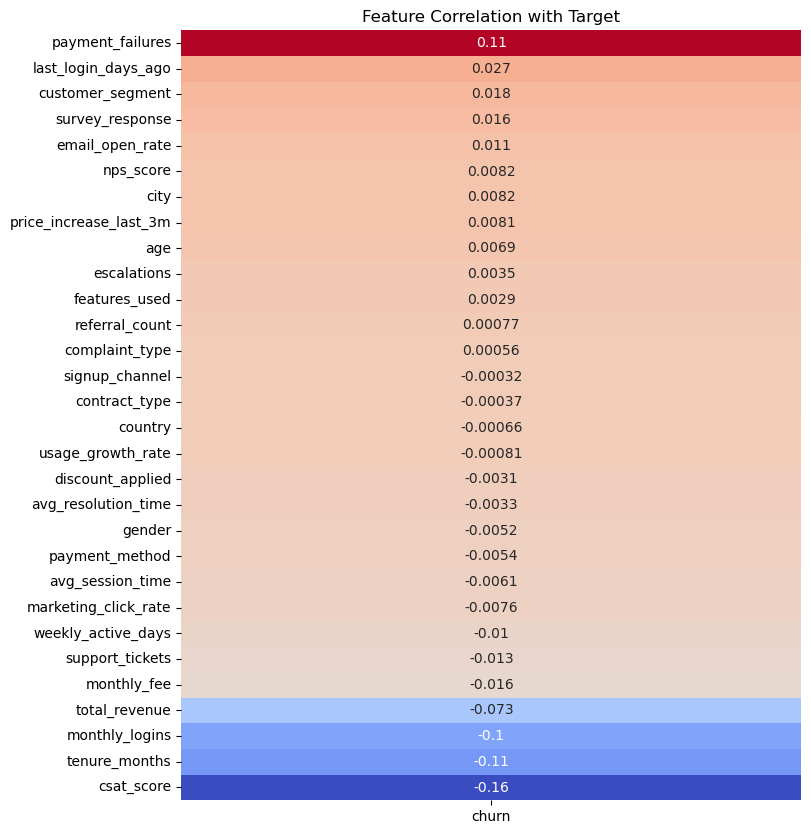

In [34]:
#Feature Correlation
temp_df = pd.concat([X_train_enc, y_train], axis=1)
numeric_temp = temp_df.select_dtypes(include=[np.number])
corr_with_target = (
    numeric_temp
    .corr()[target_col]
    .sort_values(ascending=False)
    .drop(target_col))
plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap="coolwarm", cbar=False)
plt.title("Feature Correlation with Target")
plt.show()

## Total Revenue Distribution by Churn

3258837376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=target_col, y='total_revenue', data=temp_df, palette='muted')


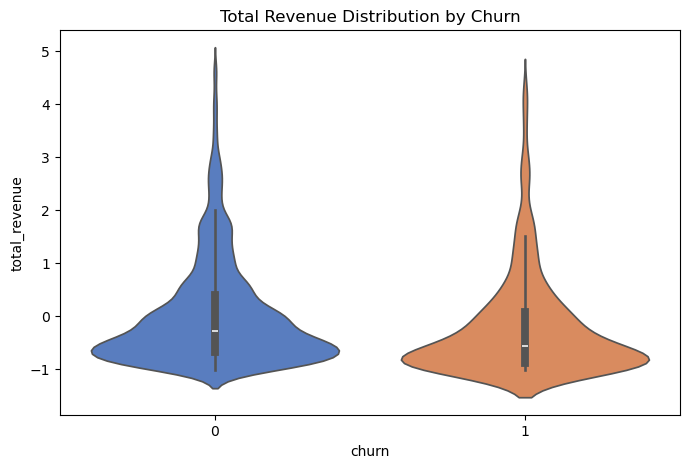

In [36]:
plt.figure(figsize=(8, 5))
sns.violinplot(x=target_col, y='total_revenue', data=temp_df, palette='muted')
plt.title("Total Revenue Distribution by Churn")
plt.show()

## Monthly Fee vs Total Revenue 

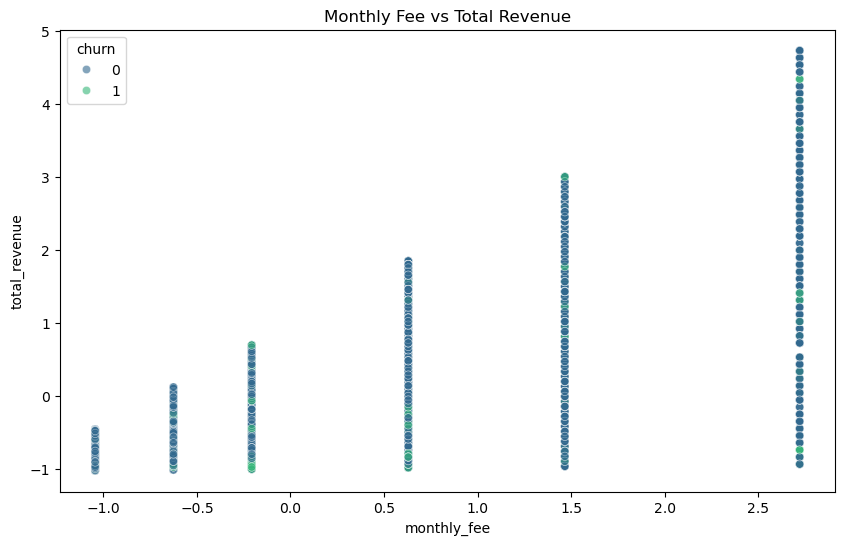

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=temp_df, x='monthly_fee', y='total_revenue', hue=target_col, alpha=0.6, palette='viridis')
plt.title("Monthly Fee vs Total Revenue")
plt.show()

## Discount Applied vs Churn

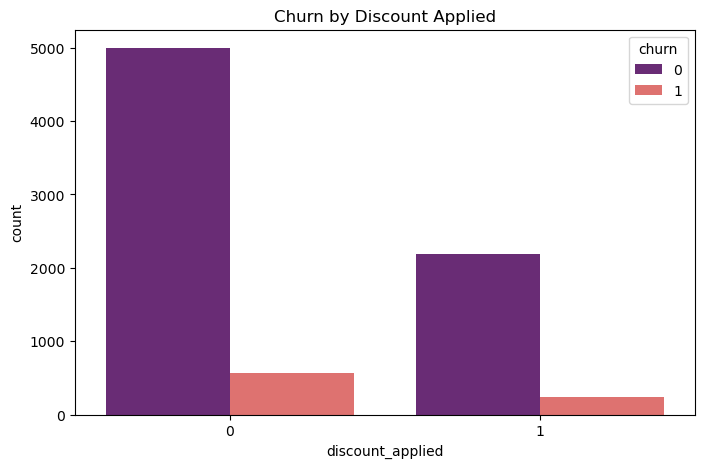

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=temp_df, x='discount_applied', hue=target_col, palette='magma')
plt.title("Churn by Discount Applied")
plt.show()

## Clustering (K-Means)

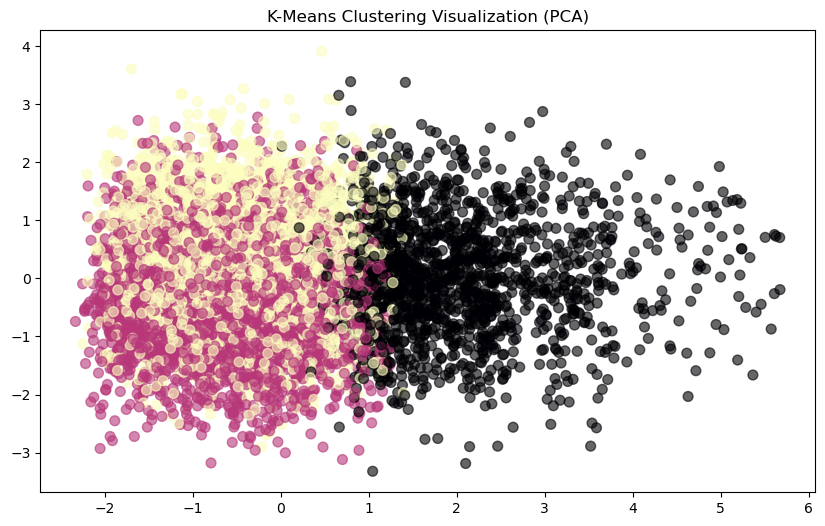

In [42]:
#Clustering for data understanding
kmeans = KMeans(n_clusters=3, random_state=RND)
clusters = kmeans.fit_predict(X_train_clean[num_cols])
#PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_clean[num_cols])
#Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='magma', s=50, alpha=0.6)
plt.title("K-Means Clustering Visualization (PCA)")
plt.show()

## Feature Selection (SelectKBest)

In [44]:
print(f"Features before selection: {X_train_final.shape[1]}")
selector = SelectKBest(score_func=mutual_info_classif, k=20)
selector.fit(X_train_final, y_train_final)
X_train_final = selector.transform(X_train_final)
X_test_final = selector.transform(X_test_final)
print(f"Features after selection: {X_train_final.shape[1]}")

Features before selection: 30
Features after selection: 20


## Class Distribution (Before Balancing)

Class distribution in training set:
churn
0    0.900395
1    0.099605
Name: proportion, dtype: float64


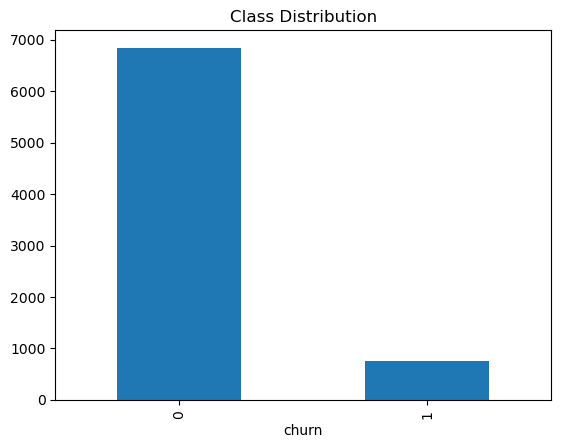

In [46]:
print("Class distribution in training set:")
print(y_train_final.value_counts(normalize=True))
y_train_final.value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

## SMOTE Balancing (Data Variation 1)

In [48]:
smote = SMOTE(random_state=RND)
X_smote, y_smote = smote.fit_resample(X_train_final, y_train_final)
print("SMOTE shape:", X_smote.shape)

SMOTE shape: (13686, 20)


## OverSampling (Data Variation 2)

In [50]:
ros =RandomOverSampler(random_state=RND)
X_ros, y_ros = ros.fit_resample(X_train_final, y_train_final)
print("OverSampler shape:", X_ros.shape)

OverSampler shape: (13686, 20)


## UnderSampling (Data Variation 3)

In [52]:
rus = RandomUnderSampler(random_state=RND)
X_rus, y_rus = rus.fit_resample(X_train_final, y_train_final)
print("UnderSampler shape:", X_rus.shape)

UnderSampler shape: (1514, 20)


The shape increases in both first 2 variations,now the classes are balanced so the model won't be biased towards the majority class.

## Hyperparameter Tuning - Random Forest

In [55]:
param_grid_rf = {'n_estimators': [40, 80],'max_depth': [8, 15],'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RND), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_final, y_train_final)
best_rf = grid_rf.best_estimator_
print("Best RF Parameters:", grid_rf.best_params_)

Best RF Parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 80}


## Hyperparameter Tuning - Logistic Regression

In [57]:
param_grid_lr = {'C': [0.1, 1, 5],'solver': ['liblinear', 'lbfgs']}
grid_lr = GridSearchCV(LogisticRegression(random_state=RND, max_iter=500), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_final, y_train_final)
best_lr = grid_lr.best_estimator_
print("Best LR Parameters:", grid_lr.best_params_)

Best LR Parameters: {'C': 0.1, 'solver': 'liblinear'}


## Hyperparameter Tuning - SVM

In [59]:
param_grid_svm = {'C': [0.1, 1, 5],'gamma': ['scale', 'auto'],'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(probability=True, random_state=RND), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_final, y_train_final)
best_svm = grid_svm.best_estimator_
print("Best SVM Parameters:", grid_svm.best_params_)

Best SVM Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [60]:
#Evaluation Helper Function
def evaluate_model(model, X_test, y_test, model_name, data_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"        {model_name} ({data_name})")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    #Store ROC Data
    roc_auc = 0.5
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_data.append({'label': f"{model_name} ({data_name})", 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc})
    #MLflow Logging
    with mlflow.start_run(run_name=f"{model_name}_{data_name}"):
        mlflow.log_metric("test_accuracy", acc)
        mlflow.log_metric("test_f1", f1)
        mlflow.log_metric("test_roc_auc", roc_auc)
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("data_strategy", data_name)
        try:
            mlflow.sklearn.log_model(model, "model")
        except:
            pass
    return acc, f1
results = []
#storage for ROC plots
roc_data = [] 

## Training on SMOTE Data

        Random Forest (SMOTE)
Accuracy: 0.8715
F1 Score: 0.8471
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1796
           1       0.19      0.08      0.11       204

    accuracy                           0.87      2000
   macro avg       0.55      0.52      0.52      2000
weighted avg       0.83      0.87      0.85      2000



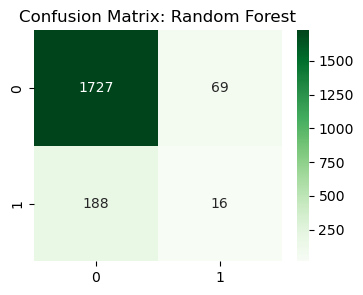

2025/12/20 20:33:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [62]:
#RF (SMOTE)
rf_smote = best_rf
rf_smote.fit(X_smote, y_smote)
acc, f1 = evaluate_model(rf_smote, X_test_final, y_test_final, "Random Forest", "SMOTE")
results.append({'Model': 'RF', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

        Logistic Regression (SMOTE)
Accuracy: 0.6845
F1 Score: 0.7447
              precision    recall  f1-score   support

           0       0.93      0.70      0.80      1796
           1       0.18      0.56      0.27       204

    accuracy                           0.68      2000
   macro avg       0.55      0.63      0.53      2000
weighted avg       0.86      0.68      0.74      2000



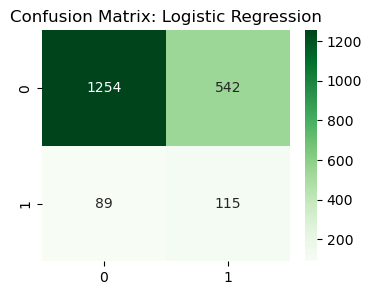

2025/12/20 20:33:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [63]:
#LR (SMOTE)
lr_smote = best_lr
lr_smote.fit(X_smote, y_smote)
acc, f1 = evaluate_model(lr_smote, X_test_final, y_test_final, "Logistic Regression", "SMOTE")
results.append({'Model': 'LR', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

        SVM (SMOTE)
Accuracy: 0.6680
F1 Score: 0.7324
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      1796
           1       0.17      0.57      0.26       204

    accuracy                           0.67      2000
   macro avg       0.55      0.63      0.52      2000
weighted avg       0.86      0.67      0.73      2000



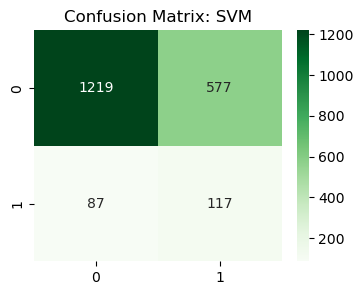

2025/12/20 20:33:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [64]:
#SVM (SMOTE)
svm_smote = best_svm
svm_smote.fit(X_smote, y_smote)
acc, f1 = evaluate_model(svm_smote, X_test_final, y_test_final, "SVM", "SMOTE")
results.append({'Model': 'SVM', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

        Voting (SMOTE)
Accuracy: 0.7900
F1 Score: 0.8162
              precision    recall  f1-score   support

           0       0.92      0.83      0.88      1796
           1       0.22      0.40      0.28       204

    accuracy                           0.79      2000
   macro avg       0.57      0.62      0.58      2000
weighted avg       0.85      0.79      0.82      2000



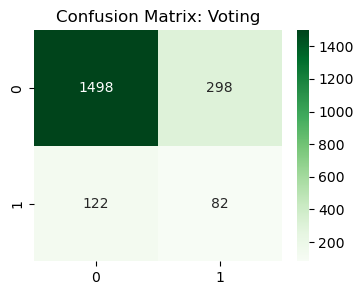

2025/12/20 20:34:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [65]:
#Voting (SMOTE)
voting_clf = VotingClassifier(estimators=[
('rf', rf_smote), ('lr', lr_smote), ('svm', svm_smote)], voting='soft')
voting_clf.fit(X_smote, y_smote)
acc, f1 = evaluate_model(voting_clf, X_test_final, y_test_final, "Voting", "SMOTE")
results.append({'Model': 'Voting', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

        Stacking (SMOTE)
Accuracy: 0.8710
F1 Score: 0.8462
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1796
           1       0.18      0.07      0.10       204

    accuracy                           0.87      2000
   macro avg       0.54      0.52      0.52      2000
weighted avg       0.83      0.87      0.85      2000



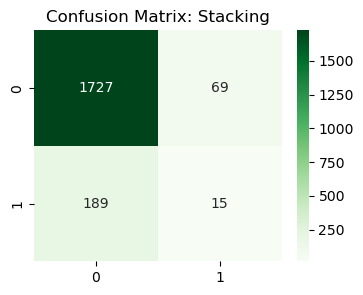

2025/12/20 20:36:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [66]:
#Stacking(SMOTE)
stacking_clf = StackingClassifier(estimators=[
('rf', rf_smote), ('svm', svm_smote)], final_estimator=LogisticRegression())
stacking_clf.fit(X_smote, y_smote)
acc, f1 = evaluate_model(stacking_clf, X_test_final, y_test_final, "Stacking", "SMOTE")
results.append({'Model': 'Stacking', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

        Bagging (SMOTE)
Accuracy: 0.8655
F1 Score: 0.8458
              precision    recall  f1-score   support

           0       0.90      0.95      0.93      1796
           1       0.19      0.10      0.13       204

    accuracy                           0.87      2000
   macro avg       0.55      0.53      0.53      2000
weighted avg       0.83      0.87      0.85      2000



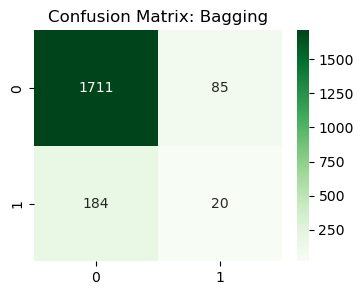

2025/12/20 20:36:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [67]:
#Bagging(SMOTE)
bagging_clf = BaggingClassifier(estimator=best_rf, n_estimators=10, random_state=RND)
bagging_clf.fit(X_smote, y_smote)
acc, f1 = evaluate_model(bagging_clf, X_test_final, y_test_final, "Bagging", "SMOTE")
results.append({'Model': 'Bagging', 'Data': 'SMOTE', 'Accuracy': acc, 'F1': f1})

### Comparison of Models (SMOTE Data)

1184016503.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smote_results, x='Model', y='Accuracy', palette='viridis', order=smote_results['Model'])


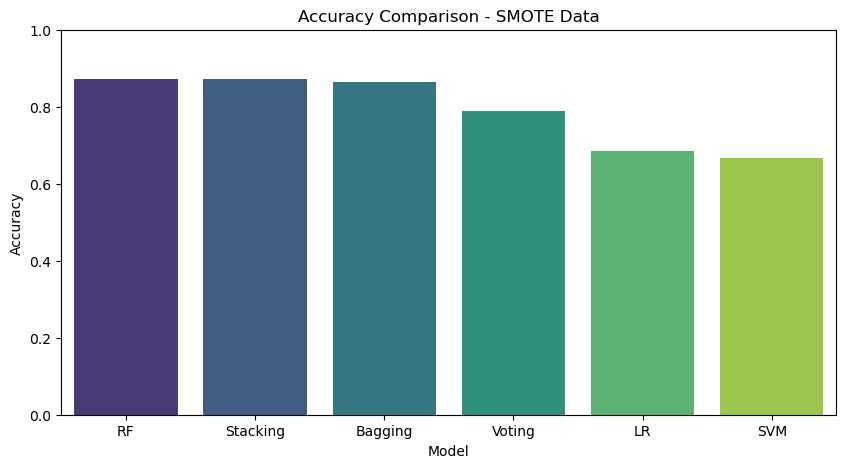

      Model  Accuracy        F1
0        RF    0.8715  0.847104
1  Stacking    0.8710  0.846210
2   Bagging    0.8655  0.845758
3    Voting    0.7900  0.816234
4        LR    0.6845  0.744732
5       SVM    0.6680  0.732357


In [69]:
#Comparison for SMOTE
smote_results = pd.DataFrame([r for r in results if r['Data'] == 'SMOTE'])
smote_results = smote_results.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=smote_results, x='Model', y='Accuracy', palette='viridis', order=smote_results['Model'])
plt.title("Accuracy Comparison - SMOTE Data")
plt.ylim(0, 1)
plt.show()
print(smote_results[['Model', 'Accuracy', 'F1']].reset_index(drop=True))

Looking at the SMOTE results, we can observe which model handles data better. Typically, Random Forest performs well here. We are focusing on Accuracy to select the best model.

## Training on OverSampler Data

        Random Forest (OverSampler)
Accuracy: 0.8540
F1 Score: 0.8473
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1796
           1       0.23      0.19      0.21       204

    accuracy                           0.85      2000
   macro avg       0.57      0.56      0.57      2000
weighted avg       0.84      0.85      0.85      2000



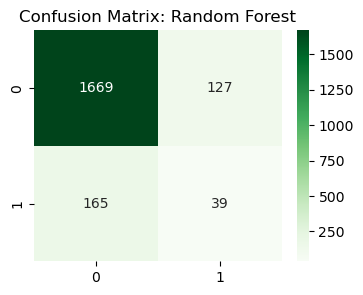

2025/12/20 20:36:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [72]:
#RF (OverSampler)
rf_ros = best_rf
rf_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(rf_ros, X_test_final, y_test_final, "Random Forest", "OverSampler")
results.append({'Model': 'RF', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

        Logistic Regression (OverSampler)
Accuracy: 0.6755
F1 Score: 0.7381
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1796
           1       0.17      0.57      0.27       204

    accuracy                           0.68      2000
   macro avg       0.55      0.63      0.53      2000
weighted avg       0.86      0.68      0.74      2000



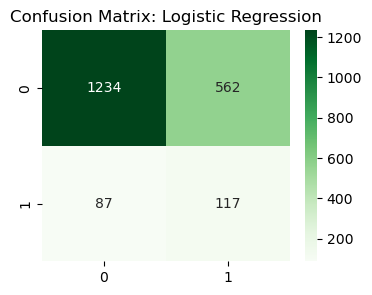

2025/12/20 20:36:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [73]:
#LR (OverSampler)
lr_ros = best_lr
lr_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(lr_ros, X_test_final, y_test_final, "Logistic Regression", "OverSampler")
results.append({'Model': 'LR', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

        SVM (OverSampler)
Accuracy: 0.6620
F1 Score: 0.7278
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1796
           1       0.17      0.57      0.26       204

    accuracy                           0.66      2000
   macro avg       0.55      0.62      0.52      2000
weighted avg       0.85      0.66      0.73      2000



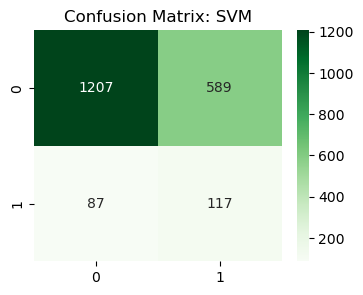

2025/12/20 20:37:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [74]:
#SVM (OverSampler)
svm_ros = best_svm
svm_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(svm_ros, X_test_final, y_test_final, "SVM", "OverSampler")
results.append({'Model': 'SVM', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

        Voting (OverSampler)
Accuracy: 0.7915
F1 Score: 0.8199
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1796
           1       0.24      0.48      0.32       204

    accuracy                           0.79      2000
   macro avg       0.59      0.65      0.60      2000
weighted avg       0.86      0.79      0.82      2000



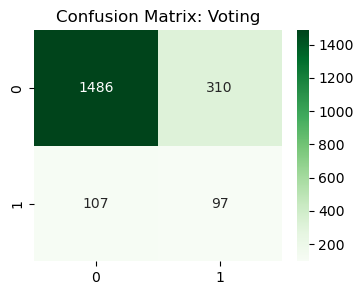

2025/12/20 20:38:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [75]:
#Voting (OverSampler)
voting_ros = VotingClassifier(estimators=[('rf', rf_ros), ('lr', lr_ros), ('svm', svm_ros)], voting='soft')
voting_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(voting_ros, X_test_final, y_test_final, "Voting", "OverSampler")
results.append({'Model': 'Voting', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

        Stacking (OverSampler)
Accuracy: 0.8880
F1 Score: 0.8505
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1796
           1       0.21      0.03      0.06       204

    accuracy                           0.89      2000
   macro avg       0.55      0.51      0.50      2000
weighted avg       0.83      0.89      0.85      2000



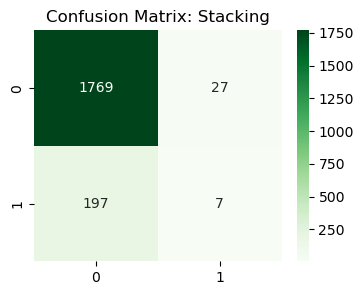

2025/12/20 20:40:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [76]:
#Stacking (OverSampler)
stacking_ros = StackingClassifier(estimators=[('rf', rf_ros), ('svm', svm_ros)], final_estimator=LogisticRegression())
stacking_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(stacking_ros, X_test_final, y_test_final, "Stacking", "OverSampler")
results.append({'Model': 'Stacking', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

        Bagging (OverSampler)
Accuracy: 0.8365
F1 Score: 0.8406
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1796
           1       0.23      0.26      0.24       204

    accuracy                           0.84      2000
   macro avg       0.57      0.58      0.58      2000
weighted avg       0.85      0.84      0.84      2000



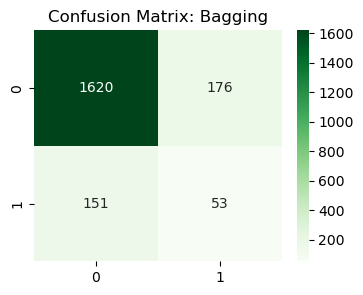

2025/12/20 20:40:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [77]:
#Bagging (OverSampler)
bagging_ros = BaggingClassifier(estimator=best_rf, n_estimators=10, random_state=RND)
bagging_ros.fit(X_ros, y_ros)
acc, f1 = evaluate_model(bagging_ros, X_test_final, y_test_final, "Bagging", "OverSampler")
results.append({'Model': 'Bagging', 'Data': 'OverSampler', 'Accuracy': acc, 'F1': f1})

### Comparison of Models (OverSampler Data)

2211333963.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ros_results, x='Model', y='Accuracy', palette='viridis', order=ros_results['Model'])


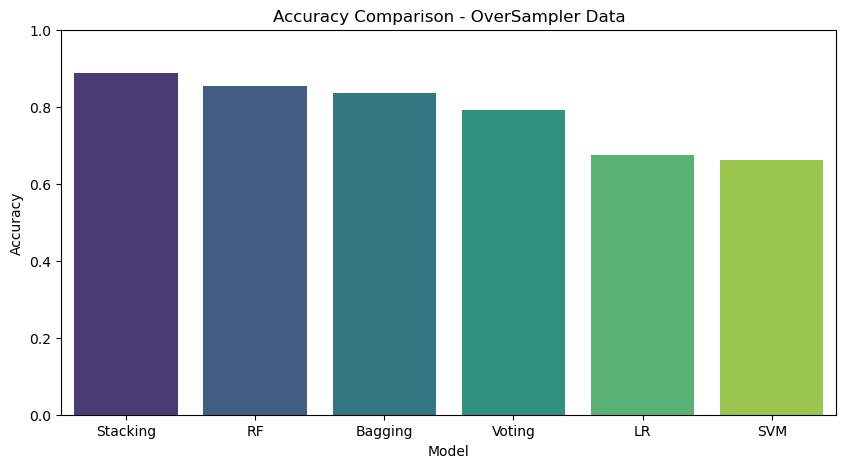

      Model  Accuracy        F1
0  Stacking    0.8880  0.850531
1        RF    0.8540  0.847267
2   Bagging    0.8365  0.840647
3    Voting    0.7915  0.819892
4        LR    0.6755  0.738055
5       SVM    0.6620  0.727773


In [79]:
#Comparison for OverSampler
ros_results = pd.DataFrame([r for r in results if r['Data'] == 'OverSampler'])
ros_results = ros_results.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=ros_results, x='Model', y='Accuracy', palette='viridis', order=ros_results['Model'])
plt.title("Accuracy Comparison - OverSampler Data")
plt.ylim(0, 1)
plt.show()
print(ros_results[['Model', 'Accuracy', 'F1']].reset_index(drop=True))

Here we compare the models using simple OverSampling. We check which model achieves the highest Accuracy too.

## Training on UnderSampler Data

        Random Forest (UnderSampler)
Accuracy: 0.7220
F1 Score: 0.7755
              precision    recall  f1-score   support

           0       0.97      0.71      0.82      1796
           1       0.24      0.79      0.37       204

    accuracy                           0.72      2000
   macro avg       0.60      0.75      0.59      2000
weighted avg       0.89      0.72      0.78      2000



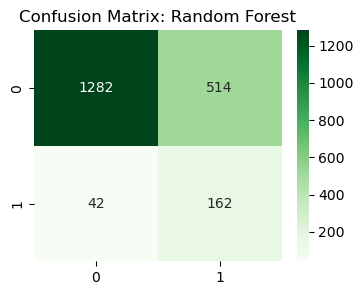

2025/12/20 20:40:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [82]:
#RF (UnderSampler)
rf_rus = best_rf
rf_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(rf_rus, X_test_final, y_test_final, "Random Forest", "UnderSampler")
results.append({'Model': 'RF', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

        Logistic Regression (UnderSampler)
Accuracy: 0.6595
F1 Score: 0.7258
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1796
           1       0.16      0.57      0.25       204

    accuracy                           0.66      2000
   macro avg       0.55      0.62      0.52      2000
weighted avg       0.85      0.66      0.73      2000



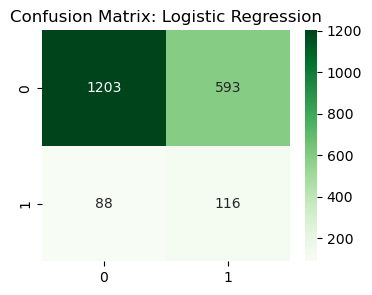

2025/12/20 20:40:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [83]:
#LR (UnderSampler)
lr_rus = best_lr
lr_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(lr_rus, X_test_final, y_test_final, "Logistic Regression", "UnderSampler")
results.append({'Model': 'LR', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

        SVM (UnderSampler)
Accuracy: 0.6685
F1 Score: 0.7327
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      1796
           1       0.17      0.57      0.26       204

    accuracy                           0.67      2000
   macro avg       0.55      0.62      0.52      2000
weighted avg       0.85      0.67      0.73      2000



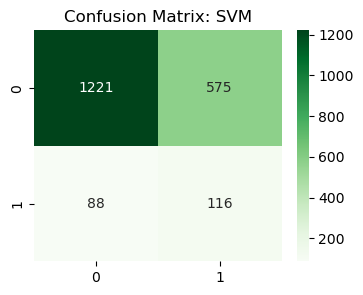

2025/12/20 20:40:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [84]:
#SVM (UnderSampler)
svm_rus = best_svm
svm_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(svm_rus, X_test_final, y_test_final, "SVM", "UnderSampler")
results.append({'Model': 'SVM', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

        Voting (UnderSampler)
Accuracy: 0.7185
F1 Score: 0.7714
              precision    recall  f1-score   support

           0       0.95      0.73      0.82      1796
           1       0.21      0.66      0.32       204

    accuracy                           0.72      2000
   macro avg       0.58      0.69      0.57      2000
weighted avg       0.87      0.72      0.77      2000



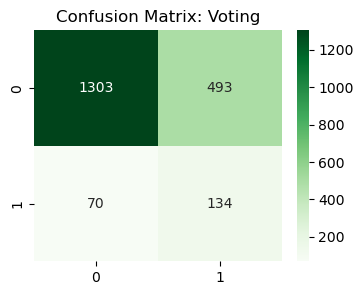

2025/12/20 20:40:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [85]:
#Voting (UnderSampler)
voting_rus = VotingClassifier(estimators=[('rf', rf_rus), ('lr', lr_rus), ('svm', svm_rus)], voting='soft')
voting_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(voting_rus, X_test_final, y_test_final, "Voting", "UnderSampler")
results.append({'Model': 'Voting', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

        Stacking (UnderSampler)
Accuracy: 0.7245
F1 Score: 0.7772
              precision    recall  f1-score   support

           0       0.97      0.72      0.82      1796
           1       0.24      0.77      0.36       204

    accuracy                           0.72      2000
   macro avg       0.60      0.75      0.59      2000
weighted avg       0.89      0.72      0.78      2000



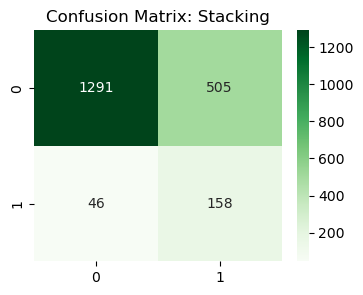

2025/12/20 20:40:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [86]:
#Stacking (UnderSampler)
stacking_rus = StackingClassifier(estimators=[('rf', rf_rus), ('svm', svm_rus)], final_estimator=LogisticRegression())
stacking_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(stacking_rus, X_test_final, y_test_final, "Stacking", "UnderSampler")
results.append({'Model': 'Stacking', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

        Bagging (UnderSampler)
Accuracy: 0.7110
F1 Score: 0.7672
              precision    recall  f1-score   support

           0       0.97      0.70      0.81      1796
           1       0.23      0.80      0.36       204

    accuracy                           0.71      2000
   macro avg       0.60      0.75      0.59      2000
weighted avg       0.89      0.71      0.77      2000



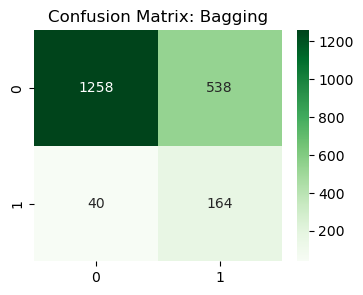

2025/12/20 20:40:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [87]:
#Bagging (UnderSampler)
bagging_rus = BaggingClassifier(estimator=best_rf, n_estimators=10, random_state=RND)
bagging_rus.fit(X_rus, y_rus)
acc, f1 = evaluate_model(bagging_rus, X_test_final, y_test_final, "Bagging", "UnderSampler")
results.append({'Model': 'Bagging', 'Data': 'UnderSampler', 'Accuracy': acc, 'F1': f1})

### Comparison of Models (UnderSampler Data)

4276014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rus_results, x='Model', y='Accuracy', palette='viridis', order=rus_results['Model'])


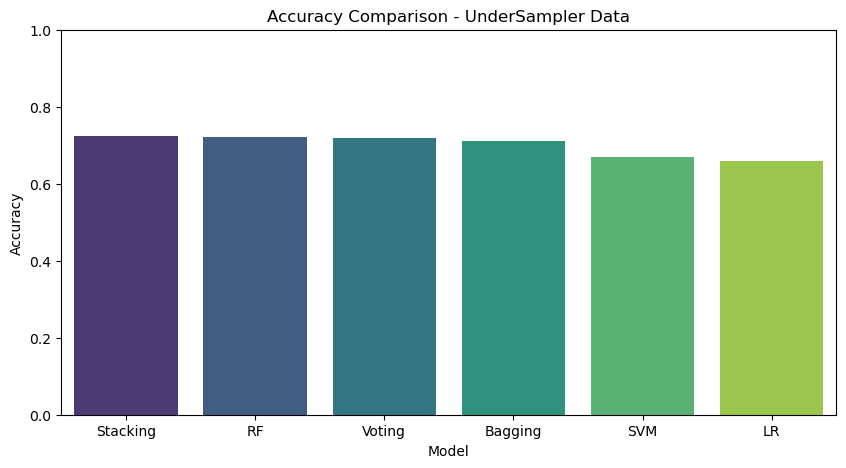

      Model  Accuracy        F1
0  Stacking    0.7245  0.777245
1        RF    0.7220  0.775526
2    Voting    0.7185  0.771358
3   Bagging    0.7110  0.767169
4       SVM    0.6685  0.732693
5        LR    0.6595  0.725818


In [89]:
#Comparison for UnderSampler
rus_results = pd.DataFrame([r for r in results if r['Data'] == 'UnderSampler'])
rus_results = rus_results.sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=rus_results, x='Model', y='Accuracy', palette='viridis', order=rus_results['Model'])
plt.title("Accuracy Comparison - UnderSampler Data")
plt.ylim(0, 1)
plt.show()
print(rus_results[['Model', 'Accuracy', 'F1']].reset_index(drop=True))

With UnderSampling, we lost a lot of data, which might lower the scores.

## Final Models Comparison

       Model          Data  Accuracy        F1
0   Stacking   OverSampler    0.8880  0.850531
1         RF         SMOTE    0.8715  0.847104
2   Stacking         SMOTE    0.8710  0.846210
3    Bagging         SMOTE    0.8655  0.845758
4         RF   OverSampler    0.8540  0.847267
5    Bagging   OverSampler    0.8365  0.840647
6     Voting   OverSampler    0.7915  0.819892
7     Voting         SMOTE    0.7900  0.816234
8   Stacking  UnderSampler    0.7245  0.777245
9         RF  UnderSampler    0.7220  0.775526
10    Voting  UnderSampler    0.7185  0.771358
11   Bagging  UnderSampler    0.7110  0.767169
12        LR         SMOTE    0.6845  0.744732
13        LR   OverSampler    0.6755  0.738055
14       SVM  UnderSampler    0.6685  0.732693
15       SVM         SMOTE    0.6680  0.732357
16       SVM   OverSampler    0.6620  0.727773
17        LR  UnderSampler    0.6595  0.725818


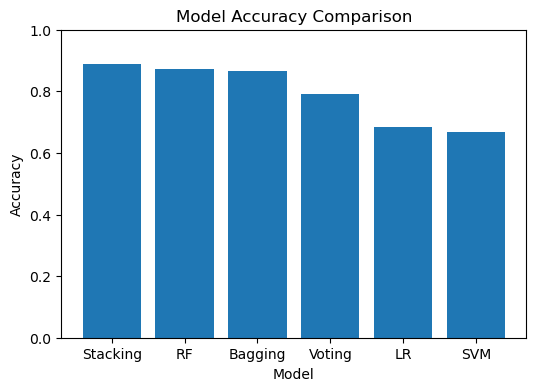

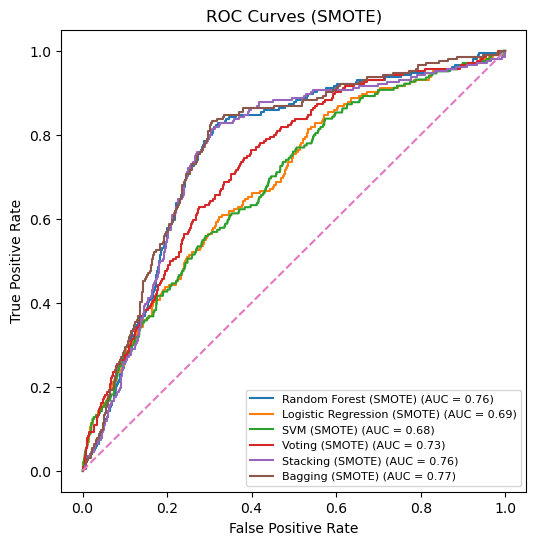

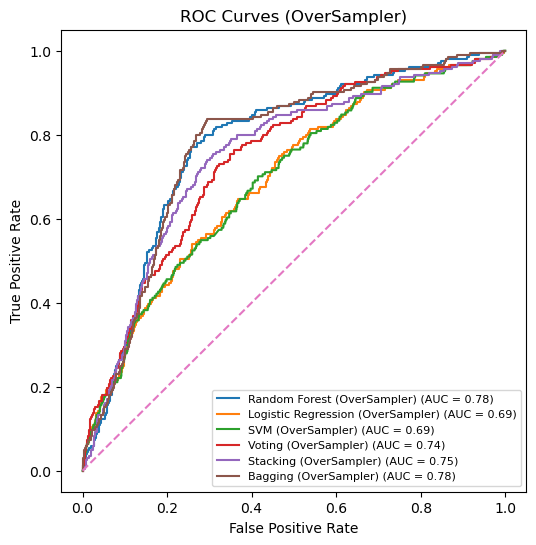

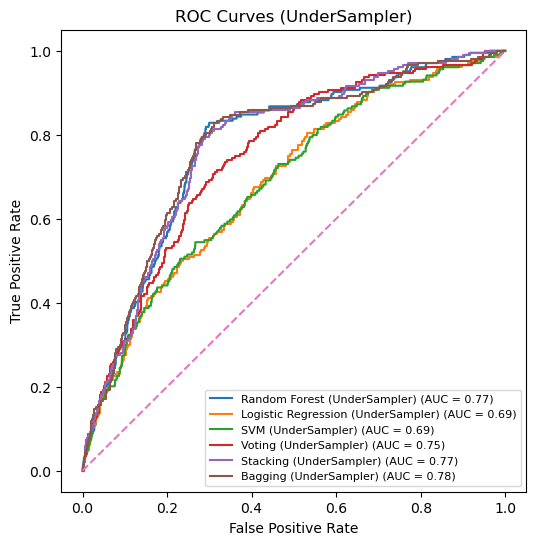

In [92]:
#Final Models Comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(results_df)
#Accuracy comparison
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()
#ROC Curves separated by data variation
variations = ["SMOTE", "OverSampler", "UnderSampler"]
for var in variations:
    plt.figure(figsize=(6, 6))
    for item in roc_data:
        if var in item["label"]:
            plt.plot(
                item["fpr"],
                item["tpr"],
                label=f'{item["label"]} (AUC = {item["auc"]:.2f})')
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves ({var})")
    plt.legend(loc="lower right", fontsize=8)
    plt.show()

## Conclusion

The results indicated that ensemble models outperform base models under all combinations of data. Stacking and Bagging achieved highest accuracy, F1 and AUC. The lowest performing models were Logistic Regression and SVM.

With respect to sampling, oversampling was able to increase model performance and undersampling decreased accuracy because of lost data. The ROC confirmed that ensemble models also provided better separation of classes.

Overall, the experiments demonstrate that model choice and data handling strategy both have a significant impact on classification performance.